In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from plots import *
import seaborn as sns


In [2]:
data_fpath = Path('stable_scores.csv') # TODO update
df = pd.read_csv(data_fpath)

df_ps_cols = pd.read_csv('df_ps_col_labels.csv')
ps_cols = df_ps_cols['ps'].values
ps_cols_labels = dict(zip(df_ps_cols['ps'], df_ps_cols['label']))

incomp_trials = pd.read_csv('incomplete_trials.csv') # TODO right place for this file?

figdir = Path('figs')
figdir.mkdir(parents=True, exist_ok=True)


### Age

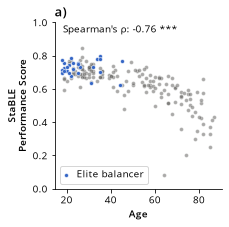

⍴ = -0.761
p < 0.001 ***


In [3]:
def plot_3a():
    xvar, xlabel = 'age', 'Age'
    yvar, ylabel = 'stable_score', 'StaBLE\nPerformance Score'

    rho, pval = stats.spearmanr(df[xvar], df[yvar])
    plt.text(0.05, 1, f'Spearman\'s ρ: {rho:.2f} {pval_stars(pval)}',
                    ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, linespacing=1.5)

    sns.scatterplot(df[~df.elite], x=xvar, y=yvar, s=15, color=cp[-1], lw=0.5, alpha=0.5)
    sns.scatterplot(df[df.elite], x=xvar, y=yvar, s=15, color=cp[2], lw=0.5, label = 'Elite balancer')

    plt.ylim(0,1)
    plt.xlabel(xlabel, fontdict={'fontweight':'semibold'})
    plt.ylabel(ylabel, fontdict={'fontweight':'semibold'})
    plt.gca().get_legend().remove()
    plt.legend(loc='lower left', handlelength=0.5)
    plt.title(f'a)', loc='left', fontdict={'weight':'semibold', 'size':13})

    return rho, pval

plt.figure(figsize=(3,3))
rho, pval = plot_3a()
plt.show()

print(f'⍴ = {rho:0.3f}')
print(pval_printer(pval), pval_stars(pval))


### Activities-Specific Balance Confidence Scale

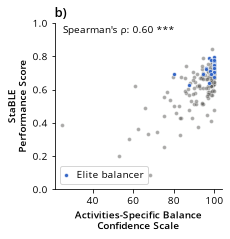

⍴ = 0.603
p < 0.001 ***
39 maximal ABC scores


In [4]:
def plot_3b():
    xvar, xlabel = 'abc_confidence_score', 'Activities-Specific Balance\nConfidence Scale'
    yvar, ylabel = 'stable_score', 'StaBLE\nPerformance Score'

    rho, pval = stats.spearmanr(df[xvar], df[yvar])
    plt.text(0.05, 1, f'Spearman\'s ρ: {rho:.2f} {pval_stars(pval)}',
                    ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, linespacing=1.5)

    sns.scatterplot(df[~df.elite], x=xvar, y=yvar, s=15, color=cp[-1], lw=0.5, alpha=0.5)
    sns.scatterplot(df[df.elite], x=xvar, y=yvar, s=15, color=cp[2], lw=0.5, label = 'Elite balancer')

    plt.ylim(0,1)
    plt.xlabel(xlabel, fontdict={'fontweight':'semibold'})
    plt.ylabel(ylabel, fontdict={'fontweight':'semibold'})
    plt.gca().get_legend().remove()
    plt.legend(loc='lower left', handlelength=0.5)
    plt.title(f'b)', loc='left', fontdict={'weight':'semibold', 'size':13})

    return rho, pval

plt.figure(figsize=(3,3))
rho, pval = plot_3b()
plt.show()

print(f'⍴ = {rho:0.3f}')
print(pval_printer(pval), pval_stars(pval))

print(np.sum(df['abc_confidence_score'] == 100), 'maximal ABC scores')


### Single Leg Stance Eyes-Closed Hold Time

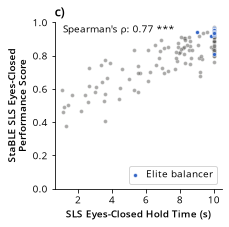

⍴ = 0.767
p < 0.001 ***
Right Eyes Closed 5 seconds: n = 34
Left Eyes Closed 5 seconds: n = 61
Both Eyes Closed 5 seconds: n = 10
SLS EC Performance Score 1: n = 0


In [5]:
# df['ps_sls_ec_time_ec_sum'] = df['sls_ec_time_r_ec'] + df['sls_ec_time_l_ec']
new_col = df['sls_ec_time_r_ec'] + df['sls_ec_time_l_ec']
df = pd.concat([df, pd.DataFrame({'ps_sls_ec_time_ec_sum':new_col})], axis=1)

def plot_3c():
    df_temp = df[~df['ps_sls_ec_time_ec_sum'].isna()]

    xvar, xlabel = 'ps_sls_ec_time_ec_sum', 'SLS Eyes-Closed Hold Time (s)'
    yvar, ylabel = 'ps_sls_ec', 'StaBLE SLS Eyes-Closed\nPerformance Score'

    rho, pval = stats.spearmanr(df_temp[xvar], df_temp[yvar])
    plt.text(0.05, 1, f'Spearman\'s ρ: {rho:.2f} {pval_stars(pval)}',
                    ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, linespacing=1.5)

    sns.scatterplot(df_temp[~df_temp.elite], x=xvar, y=yvar, s=15, color=cp[-1], lw=0.5, alpha=0.5)
    sns.scatterplot(df_temp[df_temp.elite], x=xvar, y=yvar, s=15, color=cp[2], lw=0.5, label = 'Elite balancer')

    plt.ylim(0,1)
    plt.xlabel(xlabel, fontdict={'fontweight':'semibold'})
    plt.ylabel(ylabel, fontdict={'fontweight':'semibold'})
    plt.gca().get_legend().remove()
    plt.legend(loc='lower right', handlelength=0.5)
    plt.title(f'c)', loc='left', fontdict={'weight':'semibold', 'size':13})

    return rho, pval
     
plt.figure(figsize=(3,3))
rho, pval = plot_3c()
plt.show()

print(f'⍴ = {rho:0.3f}')
print(pval_printer(pval), pval_stars(pval))

print(f'Right Eyes Closed 5 seconds: n = {(df.ps_sls_ec_time_r_ec==1).sum()}')
print(f'Left Eyes Closed 5 seconds: n = {(df.ps_sls_ec_time_l_ec==1).sum()}')
print(f'Both Eyes Closed 5 seconds: n = {(df.ps_sls_ec_time_r_ec+df.ps_sls_ec_time_l_ec==2).sum()}')
print(f'SLS EC Performance Score 1: n = {(df.ps_sls_ec==1).sum()}')


### Mini-BESTest Score for Rise to Toes

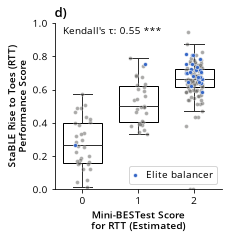

τ = 0.547
p < 0.001 ***
number of elite: 26
number of elite & miniBEST RTT = 2: 24
number of elite & miniBEST RTT= 1: 1
number of elite & miniBEST RTT= 0: 1

118 maximal miniBEST Rise-to-Toes scores
Among these, std of StaBLE scores is 0.082

24 elite balancers with maximal miniBEST Rise-to-Toes scores
Among these, std of StaBLE scores is 0.039


In [6]:
rng = np.random.default_rng(0)

xjit = rng.uniform(-1, 1, len(df)) * 0.15

def plot_3d():
    xvar, xlabel = 'miniBEST', 'Mini-BESTest Score\nfor RTT (Estimated)'
    yvar, ylabel = 'ps_rtt', 'StaBLE Rise to Toes (RTT)\nPerformance Score'

    tau, pval = stats.kendalltau(df[xvar], df[yvar])
    plt.text(0.05, 1, f'Kendall\'s τ: {tau:.2f} {pval_stars(pval)}',
                    ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, linespacing=1.5)

    plt.scatter(df[xvar][~df.elite] + xjit[~df.elite], df[yvar][~df.elite],
                s=15, c=cp[-1], edgecolors='white', lw=0.5, alpha=0.5)
    plt.scatter(df[xvar][df.elite] + xjit[df.elite], df[yvar][df.elite],
                s=15, c=cp[2], edgecolors='white', lw=0.5, label='Elite balancer')

    sns.boxplot(df, x=xvar, y=yvar, width=0.7, zorder=-1,
                boxprops=dict(facecolor='none', edgecolor='black'), 
                fliersize=0, linewidth=1)

    plt.ylim(0,1)
    plt.xlabel(xlabel, fontdict={'fontweight':'semibold'})
    plt.ylabel(ylabel, fontdict={'fontweight':'semibold'})
    plt.legend(loc='lower right', handlelength=0.5)
    plt.title(f'd)', loc='left', fontdict={'weight':'semibold', 'size':13})

    return tau, pval


plt.figure(figsize=(3,3))
tau, pval = plot_3d()
plt.show()

print(f'τ = {tau:0.3f}')
print(pval_printer(pval), pval_stars(pval))

print(f'number of elite: {df.elite.sum()}')
print(f"number of elite & miniBEST RTT = 2: {df.loc[(df.elite == True) & (df.miniBEST == 2), 'record_id'].count()}")
print(f"number of elite & miniBEST RTT= 1: {df.loc[(df.elite == True) & (df.miniBEST == 1), 'record_id'].count()}")
print(f"number of elite & miniBEST RTT= 0: {df.loc[(df.elite == True) & (df.miniBEST == 0), 'record_id'].count()}")

print()
df_maximal = df[df['miniBEST']==2]
print(f'{len(df_maximal)} maximal miniBEST Rise-to-Toes scores')
print(f'Among these, std of StaBLE scores is {df_maximal.stable_score.std():0.3f}')

print()
df_maximal = df[(df['miniBEST']==2) & (df['elite'])]
print(f'{len(df_maximal)} elite balancers with maximal miniBEST Rise-to-Toes scores')
print(f'Among these, std of StaBLE scores is {df_maximal.stable_score.std():0.3f}')


### 4-Stage Balance Test

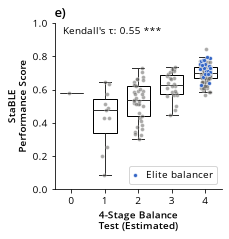

τ = 0.551
p < 0.001 ***

107 maximal 4-Stage Balance Test scores
Among these, std of StaBLE scores is 0.053


In [7]:
def plot_3e():
    xvar, xlabel = 'four_stage_bt', '4-Stage Balance\nTest (Estimated)'
    yvar, ylabel = 'stable_score', 'StaBLE\nPerformance Score'

    tau, pval = stats.kendalltau(df[xvar], df[yvar])
    plt.text(0.05, 1, f'Kendall\'s τ: {tau:.2f} {pval_stars(pval)}',
                    ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, linespacing=1.5)

    plt.scatter(df[xvar][~df.elite] + xjit[~df.elite], df[yvar][~df.elite], edgecolors='white', c=cp[-1], s=15, lw=0.5, alpha=0.5)
    plt.scatter(df[xvar][df.elite] + xjit[df.elite], df[yvar][df.elite], s=15, c=cp[2], edgecolors='white', lw=0.5, label='Elite balancer')
    sns.boxplot(df, x=xvar, y=yvar, width=0.7, zorder=-1,
                boxprops=dict(facecolor='none', edgecolor='black'), 
                fliersize=0, linewidth=1)

    plt.ylim(0,1)
    plt.xlabel(xlabel, fontdict={'fontweight':'semibold'})
    plt.ylabel(ylabel, fontdict={'fontweight':'semibold'})
    plt.legend(loc='lower right', handlelength=0.5)
    plt.title(f'e)', loc='left', fontdict={'weight':'semibold', 'size':13})

    return tau, pval


plt.figure(figsize=(3,3))
tau, pval = plot_3e()
plt.show()

print(f'τ = {tau:0.3f}')
print(pval_printer(pval), pval_stars(pval))

print()
df_maximal = df[df['four_stage_bt']==4]
print(f'{len(df_maximal)} maximal 4-Stage Balance Test scores')
print(f'Among these, std of StaBLE scores is {df_maximal.stable_score.std():0.3f}')

### Short Physical Performance Battery

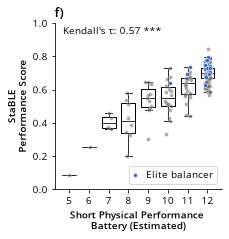

τ = 0.568
p < 0.001 ***

113 maximal SPPB scores
Among these, std of StaBLE scores is 0.054


In [8]:
def plot_3f():
    xvar, xlabel = 'sppb', 'Short Physical Performance \nBattery (Estimated)'
    yvar, ylabel = 'stable_score', 'StaBLE\nPerformance Score'

    tau, pval = stats.kendalltau(df[xvar], df[yvar])
    plt.text(0.05, 1, f'Kendall\'s τ: {tau:.2f} {pval_stars(pval)}',
                    ha='left', va='top', transform=plt.gca().transAxes, fontsize=10, linespacing=1.5)

    sns.boxplot(df, x=xvar, y=yvar,
                width=0.7, zorder=-1, dodge=False, native_scale=True,
                boxprops=dict(facecolor='none', edgecolor='black'), 
                fliersize=0, linewidth=1)
    plt.scatter(df[xvar][~df.elite] + xjit[~df.elite], df[yvar][~df.elite], edgecolors='white', c=cp[-1], s=15, lw=0.5, alpha=0.5)
    plt.scatter(df[xvar][df.elite] + xjit[df.elite], df[yvar][df.elite], s=15, c=cp[2], edgecolors='white', lw=0.5, label='Elite balancer')

    plt.ylim(0,1)
    plt.xlabel(xlabel, fontdict={'fontweight':'semibold'})
    plt.ylabel(ylabel, fontdict={'fontweight':'semibold'})
    plt.xticks(np.arange(5, 13))
    plt.legend(loc='lower right', handlelength=0.5)
    plt.title(f'f)', loc='left', fontdict={'weight':'semibold', 'size':13})
    
    return tau, pval

plt.figure(figsize=(3,3))
tau, pval = plot_3f()
plt.show()

print(f'τ = {tau:0.3f}')
print(pval_printer(pval), pval_stars(pval))

print()
df_maximal = df[df['sppb']==12]
print(f'{len(df_maximal)} maximal SPPB scores')
print(f'Among these, std of StaBLE scores is {df_maximal.stable_score.std():0.3f}')


In [9]:
df_maximal = df[(df.miniBEST == 2) & (df.four_stage_bt == 4) & (df.sppb == 12)]

print(f'{len(df_maximal)} scored maximally for miniBEST Rise-to-Toes, 4-Stage Balance Test, and SPPB')
print(f'Among these, std of StaBLE scores is: {df_maximal.stable_score.std():0.3f}')
print(f'Among these, min StaBLE score is: {df_maximal.stable_score.min():0.3f}')
print(f'Among these, max StaBLE score is: {df_maximal.stable_score.max():0.3f}')

82 scored maximally for miniBEST Rise-to-Toes, 4-Stage Balance Test, and SPPB
Among these, std of StaBLE scores is: 0.049
Among these, min StaBLE score is: 0.587
Among these, max StaBLE score is: 0.844


### Figure 4

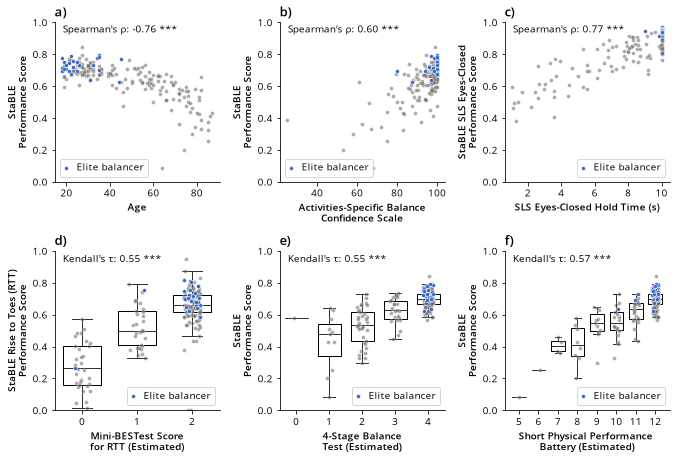

In [10]:
plt.figure(figsize=(9.5,6.5))
plt.subplot(2,3,1)
plot_3a()
plt.subplot(2,3,2)
plot_3b()
plt.subplot(2,3,3)
plot_3c()
plt.subplot(2,3,4)
plot_3d()
plt.subplot(2,3,5)
plot_3e()
plt.subplot(2,3,6)
plot_3f()
plt.tight_layout()
plt.savefig(figdir / 'fig4.pdf', transparent=True)
plt.show()